In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import matplotlib.pyplot as plt
import os
import s3fs

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [2]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [ ]:
# ds = xr.open_dataset('/tmp/ZI_mel_2015_2025.nc')
# ds.to_zarr('s3://gaia/cjense/data/melange/ZI_mel_2015_2025.zarr', consolidated=False, storage_options=storage_options)

In [3]:
melange = xr.open_dataset('s3://gaia/cjense/data/melange/ZI_mel_2015_2025.zarr', storage_options=storage_options, consolidated=False)
melange

<xarray.Dataset> Size: 10GB
Dimensions:                (time: 462, y: 1120, x: 1600)
Coordinates:
  * time                   (time) datetime64[ns] 4kB 2015-01-25 ... 2025-06-07
  * y                      (y) float64 9kB -1.067e+06 -1.067e+06 ... -1.123e+06
  * x                      (x) float64 13kB 4.6e+05 4.601e+05 ... 5.4e+05
Data variables:
    time2                  (time) datetime64[ns] 4kB ...
    velocity               (time, y, x) float32 3GB ...
    time1                  (time) datetime64[ns] 4kB ...
    velocity_over_melange  (time, y, x) float32 3GB ...
    masked_mel_velocity    (time, y, x) float32 3GB ...
    duration               (time) float64 4kB ...
    spatial_ref            int64 8B ...

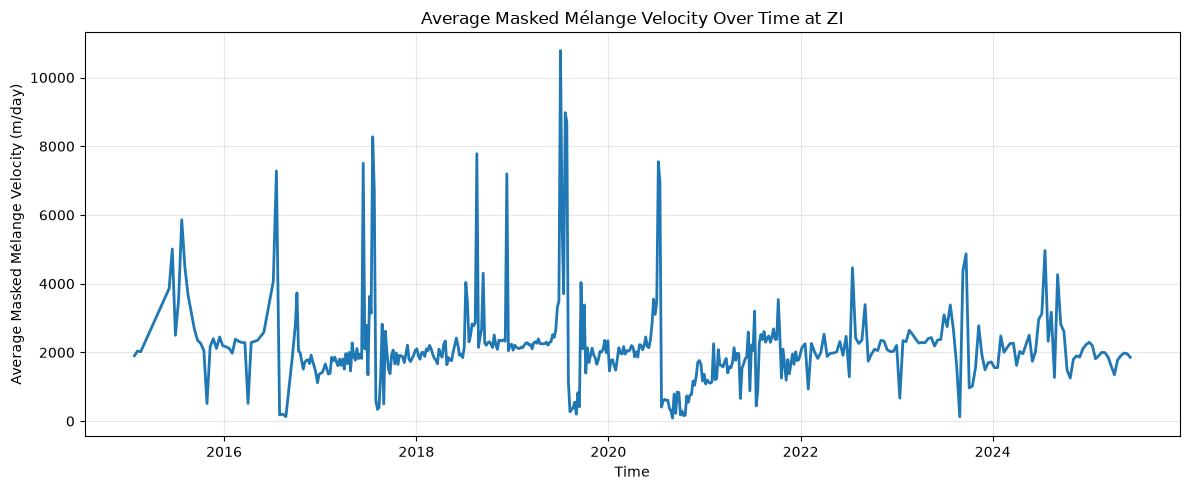

In [4]:
# Plot average masked_mel_velocity over space
avg_velocity = melange['masked_mel_velocity'].mean(dim=['y', 'x'])

fig, ax = plt.subplots(figsize=(12, 5))
avg_velocity.plot(ax=ax, linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Average Masked Mélange Velocity (m/day)')
ax.set_title('Average Masked Mélange Velocity Over Time at ZI')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/melvel_overtime_ZI.png', dpi=300)

plt.show()

In [5]:
avg_velocity

<xarray.DataArray 'masked_mel_velocity' (time: 462)> Size: 2kB
array([ 1902.2178  ,  2039.42    ,  2019.0326  ,  3858.982   ,
        5009.5137  ,  2496.7102  ,  3535.2085  ,  5859.8594  ,
        4474.1567  ,  3668.2188  ,  3164.8098  ,  2679.2126  ,
        2353.319   ,  2261.998   ,  2058.0447  ,   510.65836 ,
        2170.0369  ,  2396.8567  ,  2113.9688  ,  2448.1519  ,
        2191.25    ,  2166.2153  ,  2120.008   ,  1976.4756  ,
        2384.9653  ,  2323.0186  ,  2288.6956  ,  2283.1594  ,
         517.58514 ,  2287.2983  ,  2348.648   ,  2584.1096  ,
        4065.4827  ,  7280.7573  ,   181.35222 ,   202.83946 ,
         130.13185 ,  1838.4979  ,  2796.6648  ,  3731.7488  ,
        2035.3073  ,  1991.2454  ,  1510.5247  ,  1715.374   ,
        1770.281   ,  1787.5066  ,  1675.2756  ,  1920.2034  ,
        1730.884   ,  1586.6509  ,  1407.3263  ,  1117.8855  ,
        1351.4688  ,  1392.1191  ,  1409.8682  ,  1522.2028  ,
        1662.4436  ,  1505.6292  ,  1368.5306  ,  1396.5493  ,
        1856.983   ,  1757.4272  ,  1862.4989  ,  1725.8969  ,
        1612.4022  ,  1802.7872  ,  1623.0627  ,  1812.3516  ,
        1510.728   ,  1964.6259  ,  1673.0085  ,  1997.8163  ,
        1460.4042  ,  2276.3772  ,  1886.5231  ,  1774.1096  ,
        2112.8972  ,  1818.0009  ,  1947.3197  ,  1821.5598  ,
...
        2079.2192  ,  2024.0442  ,  2030.8214  ,  2203.0754  ,
         670.2856  ,  2341.7083  ,  2311.8474  ,  2645.448   ,
        2528.3564  ,  2392.523   ,  2271.506   ,  2287.315   ,
        2283.3247  ,  2402.9087  ,  2431.1606  ,  2184.2075  ,
        2363.3857  ,  2373.8533  ,  3092.4878  ,  2747.5898  ,
        3382.7537  ,  2648.3433  ,  1626.2876  ,   125.28244 ,
        4381.2354  ,  4870.974   ,   966.798   ,  1019.18365 ,
        1556.6162  ,  2775.4304  ,  1934.9048  ,  1494.0887  ,
        1696.517   ,  1723.2672  ,  1554.2323  ,  1554.4833  ,
        2479.9749  ,  2001.1538  ,  2139.941   ,  2262.9333  ,
        2265.4617  ,  1620.0581  ,  2027.1085  ,  1960.799   ,
        2235.5173  ,  2499.0251  ,  1740.7971  ,  2020.9146  ,
        2959.0352  ,  3125.0847  ,  4966.7607  ,  2322.346   ,
        3168.95    ,  1269.2644  ,  4261.8354  ,  2816.411   ,
        2612.011   ,  1483.6749  ,  1253.9534  ,  1803.9493  ,
        1897.7832  ,  1864.4963  ,  2103.3123  ,  2222.6082  ,
        2293.3652  ,  2201.3774  ,  1814.3352  ,  1900.2644  ,
        2002.273   ,  1992.225   ,  1863.2009  ,  1598.8898  ,
        1347.6993  ,  1777.1173  ,  1900.1428  ,  1979.7579  ,
        1966.3606  ,  1855.6791  ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-01-25 2015-02-06 ... 2025-06-07
Attributes:
    units:        meters per year
    description:  velocity (displacement) map over rigid melange region, afte...

In [ ]:
# Calculate pixel area from the spatial coordinates
pixel_width = float(abs(melange.x.diff("x").median()))
pixel_height = float(abs(melange.y.diff("y").median()))
pixel_area = pixel_width * pixel_height

# Count non-NaN pixels and calculate total valid area for each time
valid_pixels = melange["masked_mel_velocity"].notnull().sum(dim=["y", "x"])
non_nan_area = (valid_pixels * pixel_area).rename("non_nan_area")
non_nan_area.attrs["units"] = "m²"
non_nan_area.attrs["description"] = "Total area of non-NaN masked mélange velocity pixels"

# Add the result to the dataset
melange["non_nan_area"] = non_nan_area

non_nan_area

<xarray.DataArray 'non_nan_area' (time: 462)> Size: 4kB
array([1.188325e+08, 1.153250e+08, 1.227250e+08, 4.573000e+07,
       4.468000e+07, 1.268450e+08, 1.281700e+08, 9.940750e+07,
       1.028975e+08, 1.288850e+08, 8.228000e+07, 1.195775e+08,
       1.470175e+08, 1.542475e+08, 1.547200e+08, 1.407475e+08,
       1.065475e+08, 8.714250e+07, 1.237350e+08, 9.509000e+07,
       1.211750e+08, 1.205400e+08, 1.211075e+08, 1.381150e+08,
       1.390700e+08, 1.407800e+08, 1.409750e+08, 1.406475e+08,
       4.577500e+06, 1.383350e+08, 1.418025e+08, 1.311975e+08,
       7.370750e+07, 7.584750e+07, 1.917175e+08, 4.919750e+07,
       1.656500e+08, 1.217650e+08, 8.201750e+07, 3.239500e+07,
       9.193250e+07, 8.998250e+07, 9.955000e+07, 1.075750e+08,
       1.109175e+08, 1.095700e+08, 1.259900e+08, 1.152600e+08,
       1.143375e+08, 1.126250e+08, 1.230000e+08, 1.541700e+08,
       1.299925e+08, 1.363650e+08, 1.291575e+08, 1.284850e+08,
       1.288650e+08, 1.292650e+08, 1.311650e+08, 1.397000e+08,
       1.306925e+08, 1.197375e+08, 1.195425e+08, 1.194025e+08,
       1.196300e+08, 1.203775e+08, 1.176625e+08, 1.175500e+08,
       1.153050e+08, 7.890000e+07, 9.794500e+07, 7.739000e+07,
       1.054425e+08, 6.743250e+07, 8.165750e+07, 9.409500e+07,
       8.125250e+07, 1.054125e+08, 1.089500e+08, 1.319550e+08,
...
       2.334925e+08, 2.280600e+08, 2.266025e+08, 2.247825e+08,
       7.362500e+06, 2.431325e+08, 2.470125e+08, 2.449525e+08,
       2.420450e+08, 2.519250e+08, 2.500225e+08, 2.588525e+08,
       2.600125e+08, 2.680200e+08, 2.704600e+08, 2.930900e+08,
       2.727175e+08, 2.862400e+08, 2.612525e+08, 1.979750e+08,
       2.783575e+08, 1.594150e+08, 1.139475e+08, 2.563825e+08,
       3.008650e+08, 4.754350e+08, 2.896500e+08, 2.077500e+08,
       1.478825e+08, 1.543325e+08, 1.542150e+08, 1.838975e+08,
       1.661175e+08, 1.743300e+08, 1.828275e+08, 1.873525e+08,
       1.775975e+08, 1.968450e+08, 2.338425e+08, 2.204575e+08,
       2.124425e+08, 2.224675e+08, 1.954150e+08, 1.997000e+08,
       1.995925e+08, 2.051850e+08, 2.617250e+08, 2.609425e+08,
       2.584550e+08, 2.911825e+08, 3.695925e+08, 1.126150e+08,
       1.097700e+08, 1.305650e+08, 3.941225e+08, 4.872650e+08,
       3.360350e+08, 1.891325e+08, 2.162325e+08, 1.882050e+08,
       2.099475e+08, 2.513375e+08, 2.615925e+08, 2.481475e+08,
       2.905275e+08, 2.900475e+08, 4.349050e+08, 4.581850e+08,
       4.517100e+08, 4.283550e+08, 4.192350e+08, 4.163650e+08,
       2.890075e+08, 3.121425e+08, 2.972475e+08, 2.965700e+08,
       2.947850e+08, 3.240075e+08])
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-01-25 2015-02-06 ... 2025-06-07
Attributes:
    units:        m²
    description:  Total area of non-NaN masked mélange velocity pixels

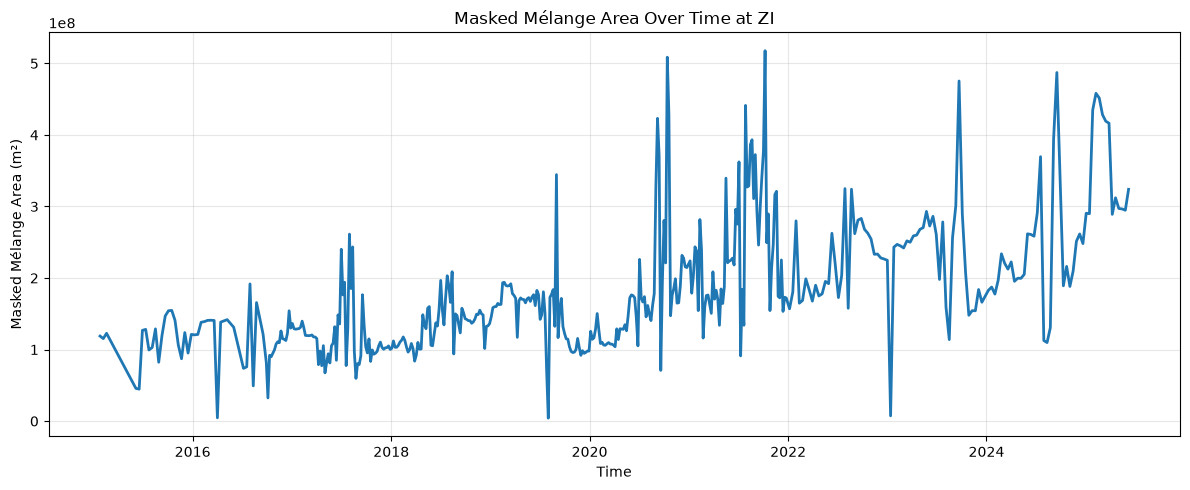

In [7]:
# Plot area of masked_mel_velocity

fig, ax = plt.subplots(figsize=(12, 5))
non_nan_area.plot(ax=ax, linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Masked Mélange Area (m²)')
ax.set_title('Masked Mélange Area Over Time at ZI')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/melarea_overtime_ZI.png', dpi=300)

plt.show()

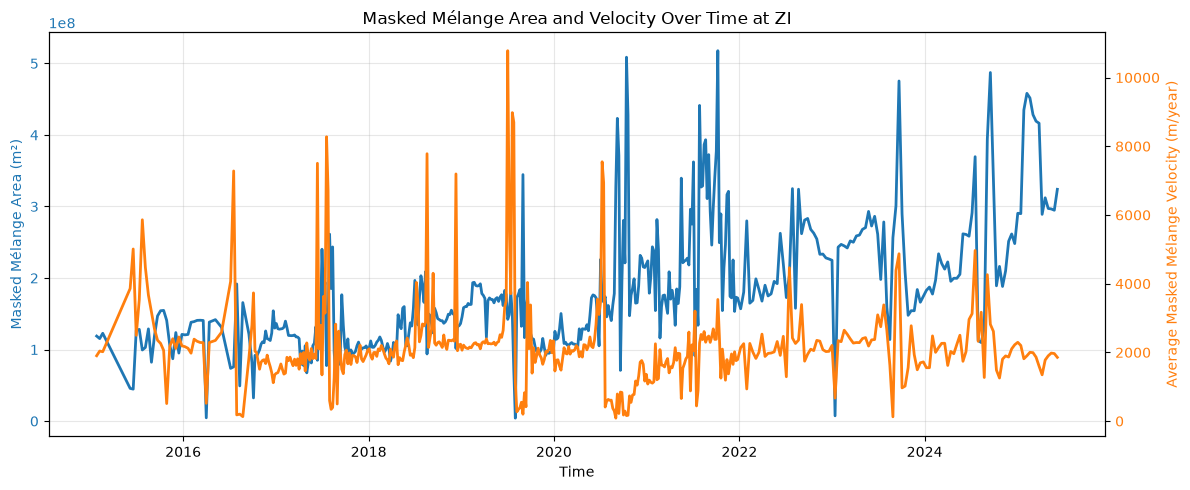

<Figure size 640x480 with 0 Axes>

In [9]:
# Plot area and velocity with separate y-axes

fig, ax1 = plt.subplots(figsize=(12, 5))

non_nan_area.plot(ax=ax1, linewidth=2, color='tab:blue', label='Area')
ax1.set_xlabel('Time')
ax1.set_ylabel('Masked Mélange Area (m²)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
avg_velocity.plot(ax=ax2, linewidth=2, color='tab:orange', label='Velocity')
ax2.set_ylabel('Average Masked Mélange Velocity (m/year)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Masked Mélange Area and Velocity Over Time at ZI')
ax1.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig('figures/mel_area_velocity_ZI.png', dpi=300)
plt.show()
ax.set_title('Masked Mélange Area Over Time at ZI')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figures/mel_area_velocity_ZI.png', dpi=300)

plt.show()

In [10]:
non_nan_area_df = non_nan_area.to_dataframe()
non_nan_area_df.to_parquet('s3://gaia/cjense/data/melange/melange_area.parquet', storage_options=storage_options)

avg_velocity_df = avg_velocity.to_dataframe()
avg_velocity_df.to_parquet('s3://gaia/cjense/data/melange/melange_vel.parquet', storage_options=storage_options)

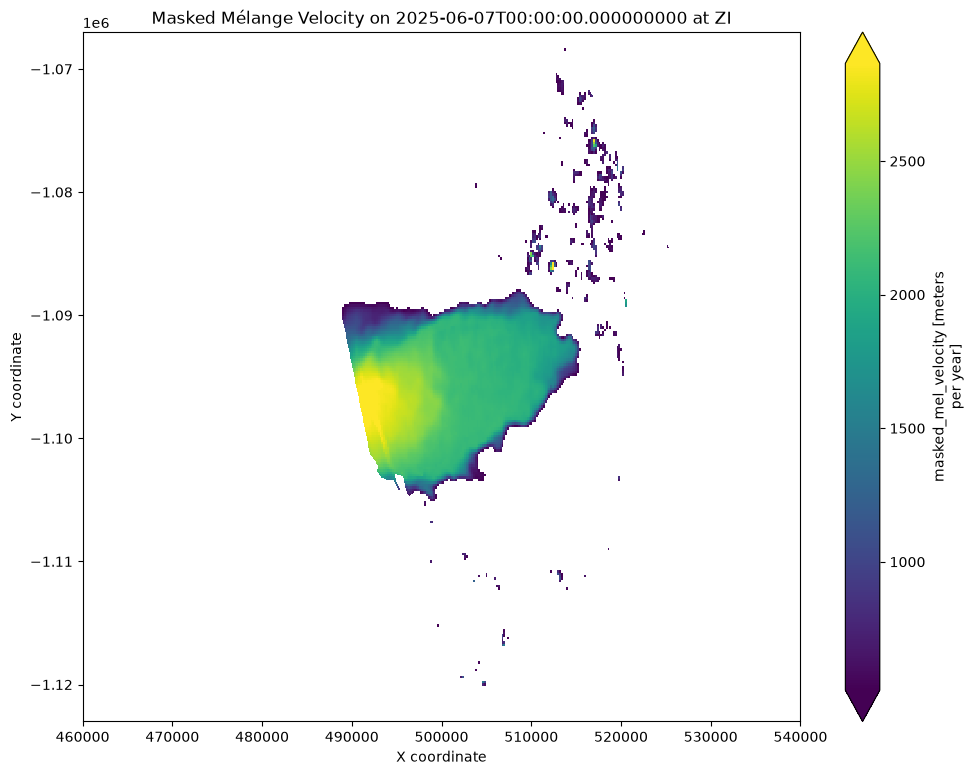

In [6]:
# Plot spatial distribution at a single time
# Using the latest date in the dataset
time_idx = -1
data_at_time = melange['masked_mel_velocity'].isel(time=time_idx)

fig, ax = plt.subplots(figsize=(10, 8))
data_at_time.plot(ax=ax, cmap='viridis', robust=True)
ax.set_title(f'Masked Mélange Velocity on {melange.time.isel(time=time_idx).values} at ZI')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
plt.tight_layout()

plt.savefig('figures/melvel_20250607_ZI.png', dpi=300)
plt.show()